<a href="https://colab.research.google.com/github/OnyxxSan/projects/blob/main/DS_Car_Price_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First I loaded my data set and used pandas to take a look at the first 5 rows and ensure it works well on colab.

In [4]:
import pandas as pd

df = pd.read_csv('/content/used_cars.csv')
display(df.head())

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


Here I began to clean the data by coverting milage and price to numeric values and rem,ove missing values in the data set. This step also gave me a good glimpse of the size of the dataset and other important metrics.

In [5]:
# Drop rows with any missing values
df_cleaned = df.dropna().copy()

# Clean 'milage' column: remove ' mi.' and ',' then convert to numeric
df_cleaned['milage'] = df_cleaned['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '').astype(float)

# Clean 'price' column: remove '$' and ',' then convert to numeric
df_cleaned['price'] = df_cleaned['price'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)

print("DataFrame Info after dropping rows with missing values and converting types:")
df_cleaned.info()

print("\nNumber of missing values after dropping rows:")
print(df_cleaned.isnull().sum())

print("\nDataFrame head after cleaning:")
display(df_cleaned.head())

DataFrame Info after dropping rows with missing values and converting types:
<class 'pandas.core.frame.DataFrame'>
Index: 3269 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         3269 non-null   object 
 1   model         3269 non-null   object 
 2   model_year    3269 non-null   int64  
 3   milage        3269 non-null   float64
 4   fuel_type     3269 non-null   object 
 5   engine        3269 non-null   object 
 6   transmission  3269 non-null   object 
 7   ext_col       3269 non-null   object 
 8   int_col       3269 non-null   object 
 9   accident      3269 non-null   object 
 10  clean_title   3269 non-null   object 
 11  price         3269 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 332.0+ KB

Number of missing values after dropping rows:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
6,Audi,S3 2.0T Premium Plus,2017,84000.0,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000.0
7,BMW,740 iL,2001,242000.0,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300.0


The first thing I wanted to look at was price with respect to milage on a scatterplot. I used seasborn and matplotlib here create the scatterplot with the cleaned data and used a regression line to better visualize the negative slope indicating a negative relationship between milage and price.

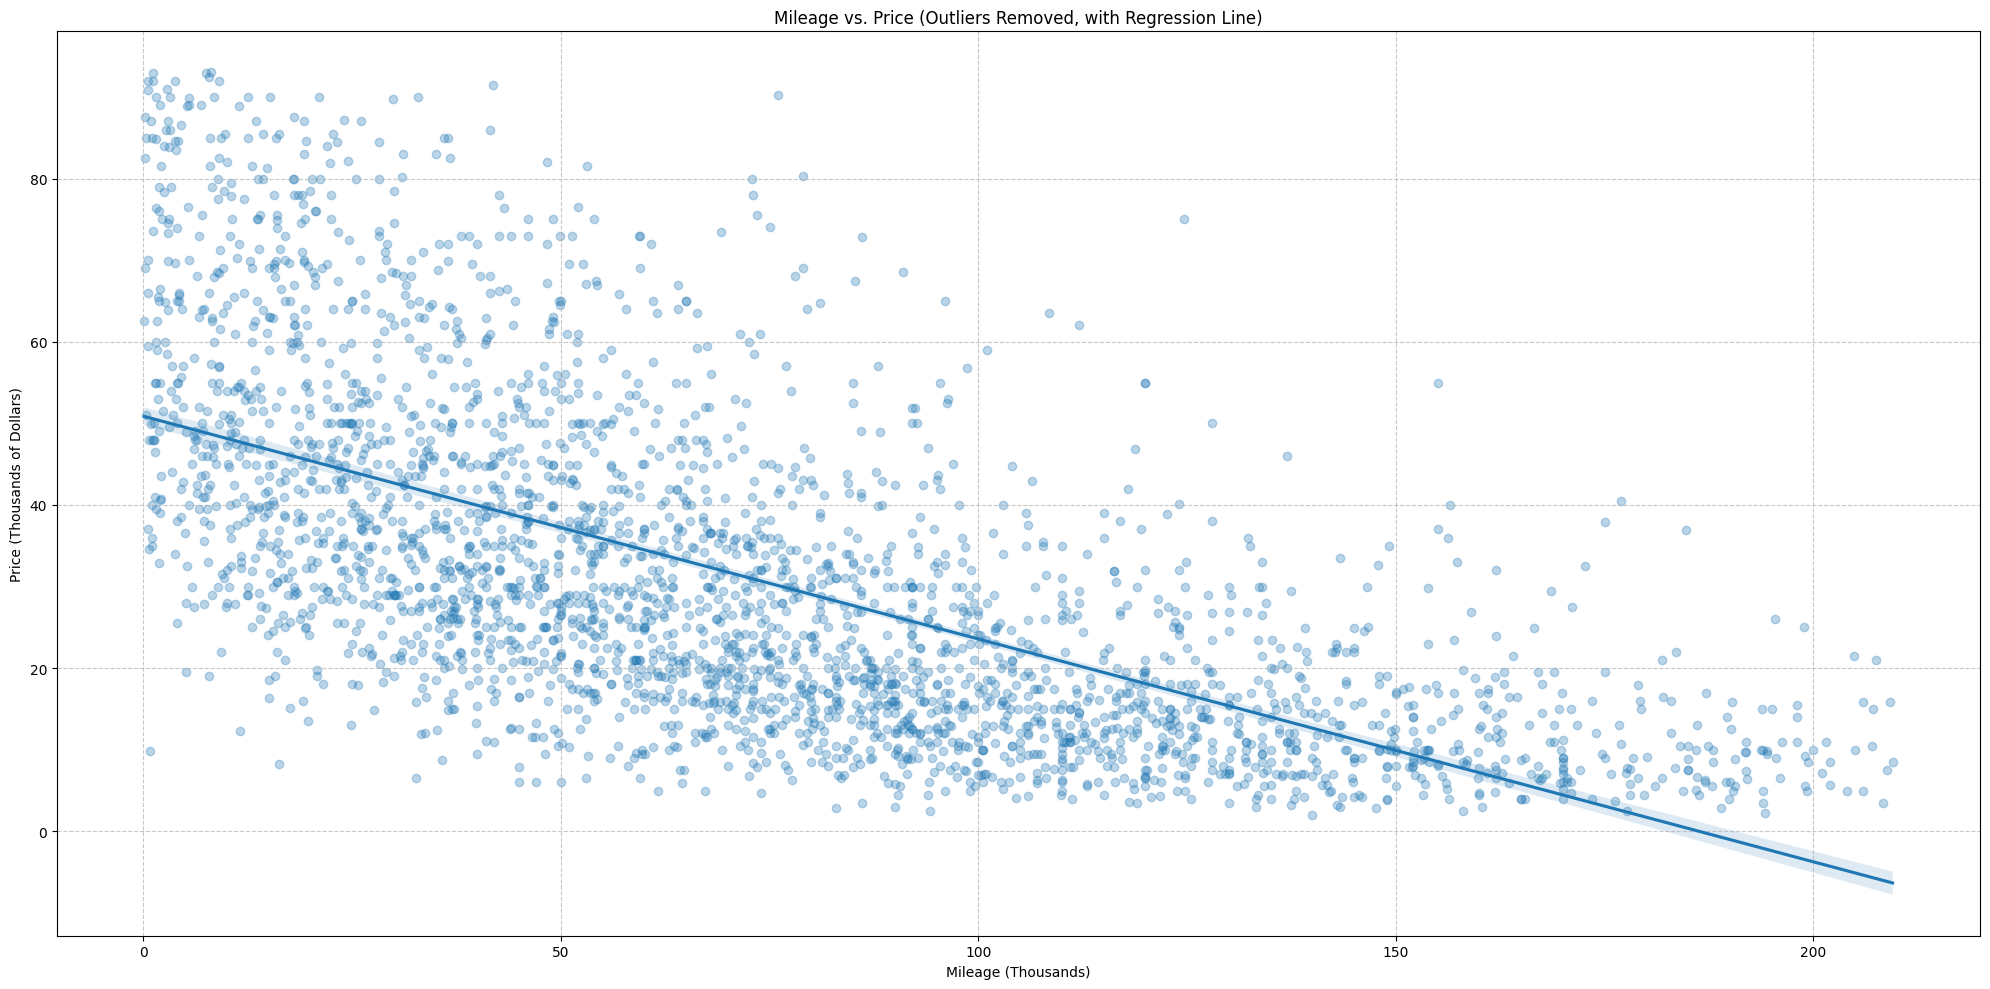

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 10))
sns.regplot(x=df_no_outliers['milage'] / 1000, y=df_no_outliers['price'] / 1000, scatter_kws={'alpha':0.3})
plt.title('Mileage vs. Price (Outliers Removed, with Regression Line)')
plt.xlabel('Mileage (Thousands)')
plt.ylabel('Price (Thousands of Dollars)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Using matplotlib and seasborn further I used a correlation matrix to look at the relationships between the various car features such a price, milage, model year. This matrix showed negative relationships between price and model year, mileage and model year, and milage and price.

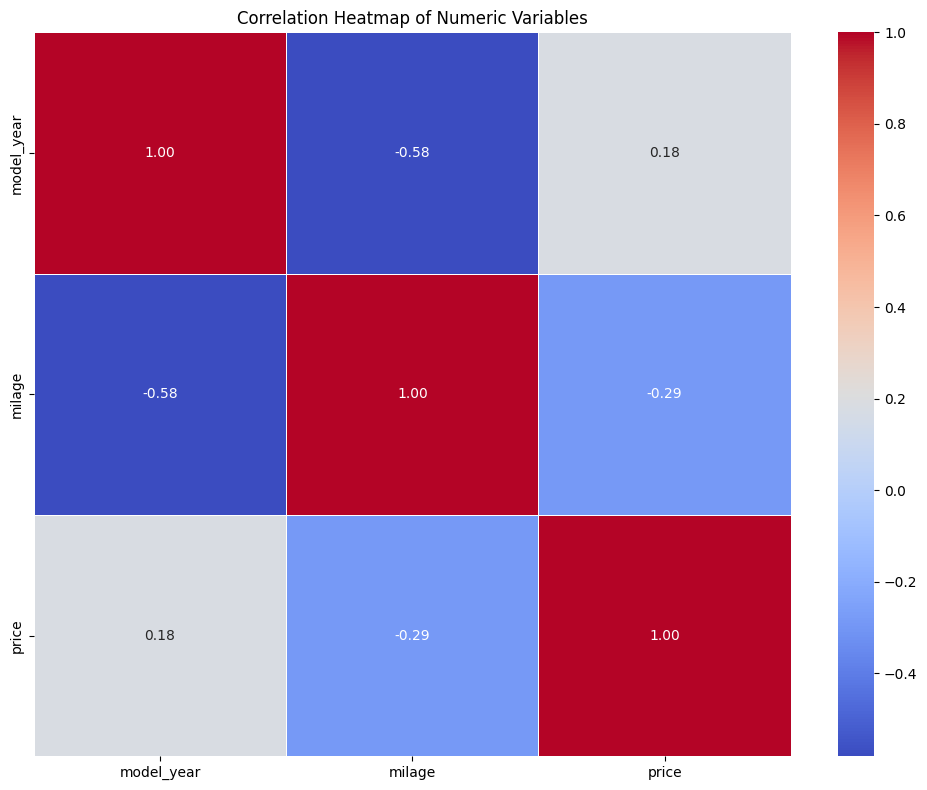

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation calculation
numeric_df = df_cleaned.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

Here I graphed a box plot to identify outliers in price in the data set so we can remove them.

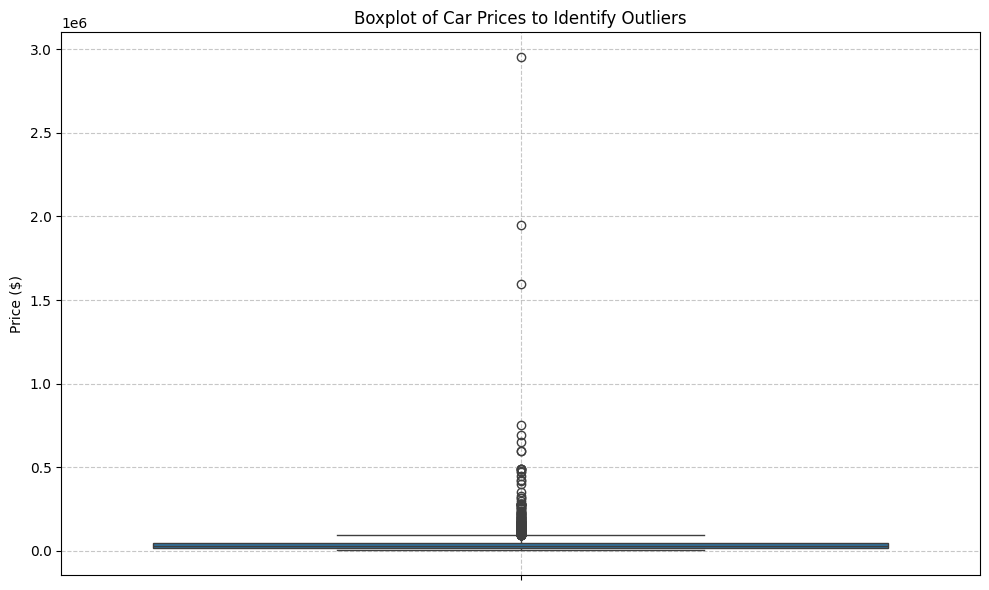

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df_cleaned['price'])
plt.title('Boxplot of Car Prices to Identify Outliers')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Next I created another scatterplot with the removed price outliers to see if the plot looked cleaner.

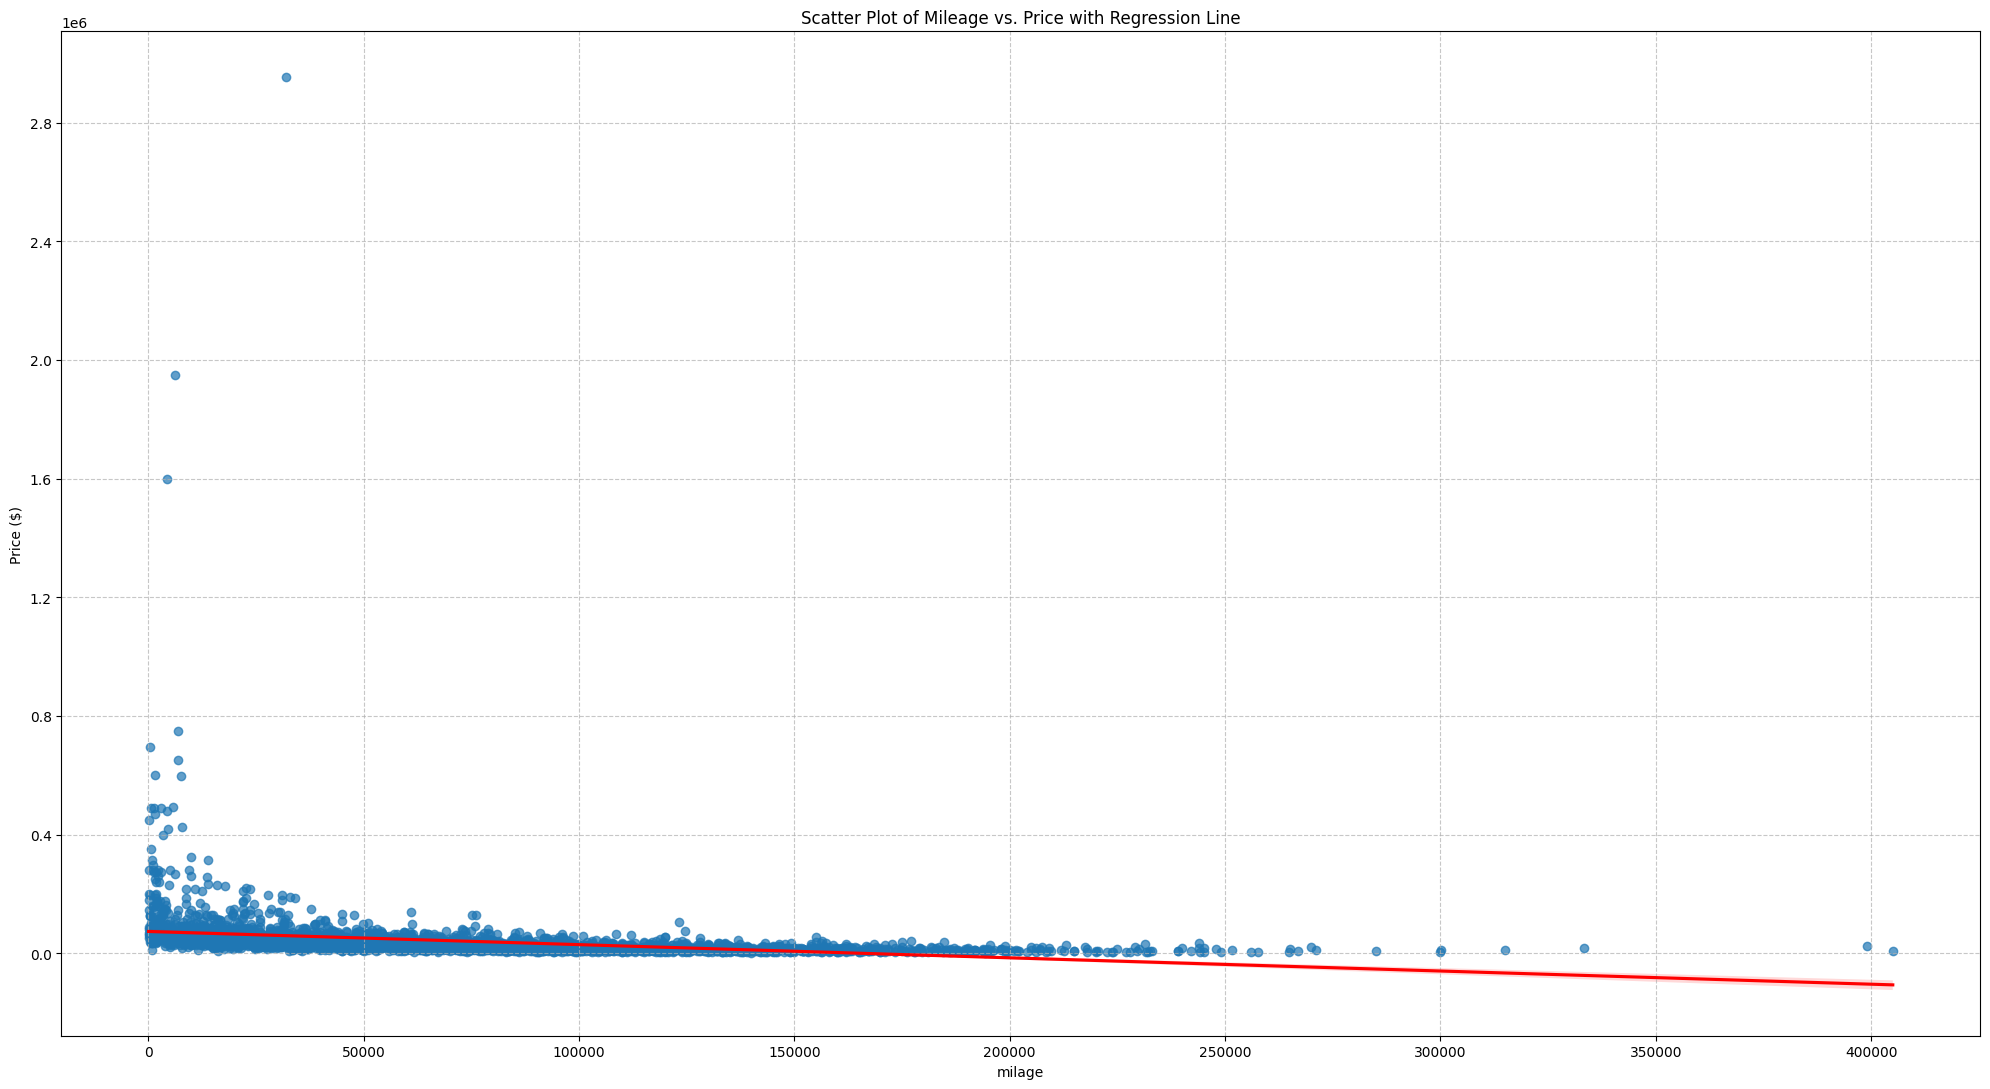

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator # Import MaxNLocator

plt.figure(figsize=(20, 11))
sns.regplot(x='milage', y='price', data=df_cleaned, scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
plt.title('Scatter Plot of Mileage vs. Price with Regression Line')
plt.xlabel('milage')
plt.ylabel('Price ($)')

# Use MaxNLocator to automatically choose good tick locations for the y-axis
# It tries to find up to 10 nicely spaced major ticks, often rounded to significant numbers.
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=10))

# Use MaxNLocator to automatically choose good tick locations for the x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=10))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
# Calculate IQR for 'price'
Q1_price = df_cleaned['price'].quantile(0.25)
Q3_price = df_cleaned['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

# Calculate IQR for 'milage'
Q1_milage = df_cleaned['milage'].quantile(0.25)
Q3_milage = df_cleaned['milage'].quantile(0.75)
IQR_milage = Q3_milage - Q1_milage

lower_bound_milage = Q1_milage - 1.5 * IQR_milage
upper_bound_milage = Q3_milage + 1.5 * IQR_milage

# Filter out outliers
df_no_outliers = df_cleaned[
    (df_cleaned['price'] >= lower_bound_price) & (df_cleaned['price'] <= upper_bound_price) &
    (df_cleaned['milage'] >= lower_bound_milage) & (df_cleaned['milage'] <= upper_bound_milage)
].copy()

print(f"Original number of rows: {len(df_cleaned)}")
print(f"Number of rows after outlier removal: {len(df_no_outliers)}")

# Display the head of the new DataFrame
display(df_no_outliers.head())

Original number of rows: 3269
Number of rows after outlier removal: 3033


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
6,Audi,S3 2.0T Premium Plus,2017,84000.0,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000.0
8,Lexus,RC 350 F Sport,2021,23436.0,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,41927.0


Here I began training a regression model that predicts car prices based on milage and price only. The model gives a mean squarred error and R^2 since I haven't incorpated other features into the model.

In [11]:

X = df_no_outliers[['milage']]
y = df_no_outliers['price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")



Mean Squared Error: 244129725.90799826
R-squared: 0.44175783020286297


### Feature Engineering: Incorporating Additional Features

To improve the model's predictive power, I will add more relevant features. Specifically, I'll include 'model_year' and convert categorical features like 'brand', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', and 'clean_title' into numerical format using one-hot encoding.

In [12]:
# Identify numerical and categorical features
numerical_features = ['milage', 'model_year']
categorical_features = ['brand', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

# Create a copy to avoid modifying the original DataFrame directly
df_model = df_no_outliers.copy()

# One-hot encode categorical features
df_model = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

# Define the feature matrix X with numerical and encoded categorical features
X_new = df_model[numerical_features + [col for col in df_model.columns if col.startswith(tuple(categorical_features))]]
y_new = df_model['price']

print("New feature matrix X_new head:")
display(X_new.head())
print(f"Shape of new feature matrix X_new: {X_new.shape}")

New feature matrix X_new head:


,milage,model_year,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Buick,brand_Cadillac,brand_Chevrolet,...,int_col_Shale,int_col_Shara Beige,int_col_Silver,int_col_Sport,int_col_Titan Black / Quarzit,int_col_White,int_col_White / Brown,int_col_Yellow,int_col_–,accident_None reported
0,51000.0,2013,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,34742.0,2021,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,88900.0,2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6,84000.0,2017,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
8,23436.0,2021,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


Shape of new feature matrix X_new: (3033, 1121)


### Retraining the Model with Expanded Features

Now, I will split the data into training and testing sets, train a new Linear Regression model using the expanded feature set, and then evaluate its performance.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# Train a new Linear Regression model
model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

# Make predictions on the test set
y_pred_new = model_new.predict(X_test_new)

# Evaluate the new model
mse_new = mean_squared_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print(f"Mean Squared Error (New Model): {mse_new}")
print(f"R-squared (New Model): {r2_new}")

Mean Squared Error (New Model): 103275042.65808342
R-squared (New Model): 0.7638448833508007


### Implementing Random Forest Regressor

I will now use the Random Forest Regressor model, which is an ensemble learning method, to potentially capture more complex patterns in the data and further improve the predictive accuracy. I'll use the same `X_new` and `y_new` datasets that include the engineered features.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Random Forest Regressor model
# You can adjust hyperparameters like n_estimators, max_depth, etc., for further tuning
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train_new, y_train_new)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_new)

# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test_new, y_pred_rf)
r2_rf = r2_score(y_test_new, y_pred_rf)

print(f"Mean Squared Error (Random Forest Model): {mse_rf}")
print(f"R-squared (Random Forest Model): {r2_rf}")

Mean Squared Error (Random Forest Model): 124850657.40582602
R-squared (Random Forest Model): 0.7145087447601812


### Feature Importance from Random Forest Model

Let's visualize the importance of each feature as determined by the Random Forest Regressor. This can help in understanding which car attributes are most influential in predicting its price.

/tmp/ipykernel_8019/2623067151.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


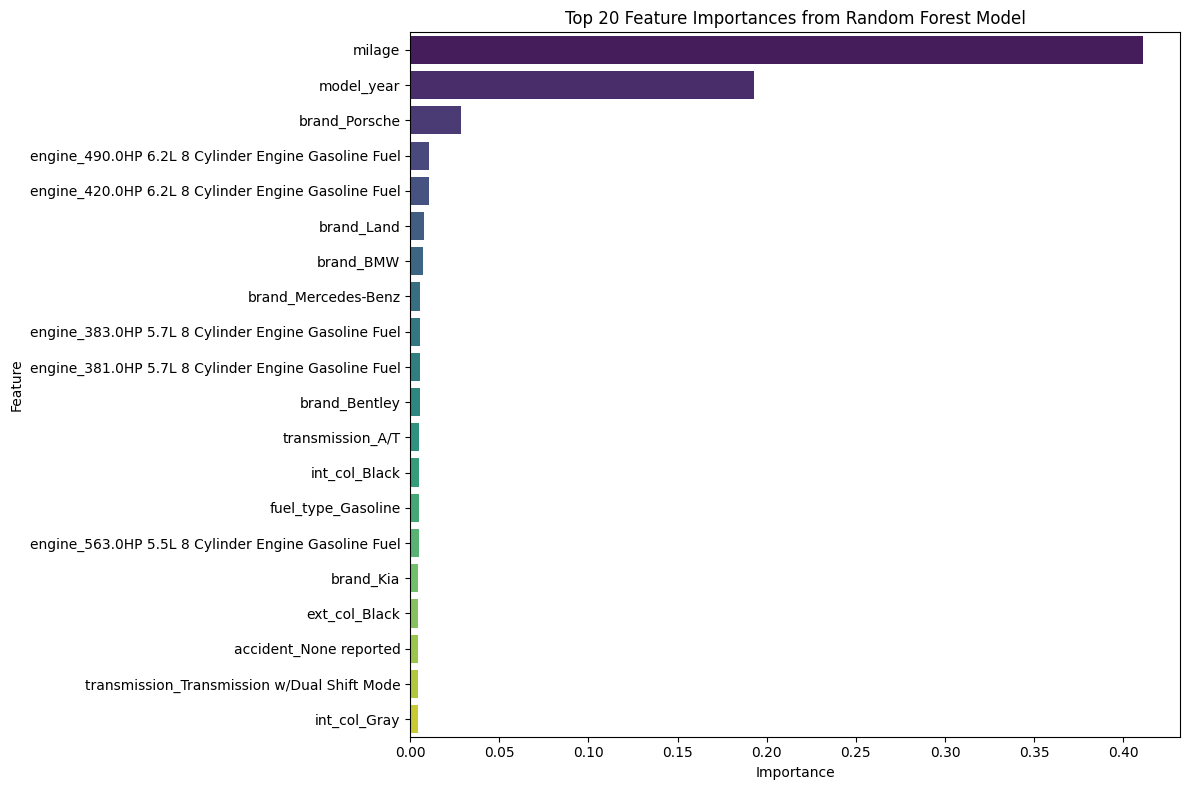

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from X_new.columns
feature_names = X_new.columns

# Create a Series for better handling and sorting
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order and select the top N (e.g., top 20)
top_n = 20
top_features = importance_df.nlargest(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title(f'Top {top_n} Feature Importances from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Model Performance Comparison

Let's compare the performance metrics (Mean Squared Error and R-squared) for the different models we've trained:

| Model                                         | Mean Squared Error  | R-squared |
|:----------------------------------------------|:--------------------|:----------|
| Initial Linear Regression (Milage only)       | 244,129,725.91      | 0.44      |
| Linear Regression (with all features)         | 103,275,042.66      | 0.76      |
| Random Forest Regressor (Initial)             | 124,850,657.41      | 0.71      |
| Random Forest Regressor (Optimized by GridSearchCV) | 131,595,507.50      | 0.69      |

From this table, the **Linear Regression model with all engineered features** still demonstrates the best performance with the lowest Mean Squared Error and the highest R-squared score of `0.76`.

The optimized Random Forest Regressor, despite hyperparameter tuning, did not surpass the performance of the Linear Regression model in this particular scenario, achieving an R-squared of `0.69`. This indicates that for this dataset and feature set, the linear relationships captured by the Linear Regression model are quite strong, and the Random Forest, even with tuning, might be overfitting slightly or not finding significantly better patterns.

### Car Price Prediction Applet

This section provides a function to predict car prices based on user-provided features. The function will preprocess the input to match the training data format and then use the Linear Regression model (`model_new`) to generate a prediction.

In [18]:
import pandas as pd

def predict_car_price(new_car_data, trained_model, numerical_features, categorical_features, X_train_columns):
    """
    Predicts the price of a car given its features.

    Args:
        new_car_data (dict): A dictionary containing the new car's features.
                             Example: {'milage': 50000, 'model_year': 2018, 'brand': 'Toyota', ...}
        trained_model: The trained scikit-learn model (e.g., LinearRegression).
        numerical_features (list): List of numerical feature names used during training.
        categorical_features (list): List of categorical feature names used during training.
        X_train_columns (list): A list of column names (features) that the model was trained on.
                                This is crucial for one-hot encoding alignment.

    Returns:
        float: The predicted price of the car.
    """

    # Convert new_car_data to a DataFrame
    new_df = pd.DataFrame([new_car_data])

    # Ensure 'model_year' is an integer if it's in numerical_features
    for feature in numerical_features:
        if feature in new_df.columns:
            new_df[feature] = pd.to_numeric(new_df[feature], errors='coerce')

    # Apply one-hot encoding to categorical features
    new_df_encoded = pd.get_dummies(new_df, columns=categorical_features, drop_first=True)

    # Align columns with the training data (X_new)
    # This step is critical to ensure the new data has the same columns in the same order
    # as the data the model was trained on.
    final_new_data = pd.DataFrame(columns=X_train_columns) # Create an empty DataFrame with all expected columns
    final_new_data = pd.concat([final_new_data, new_df_encoded], ignore_index=True)
    final_new_data = final_new_data.fillna(False) # Fill missing one-hot encoded columns with False (0)
    final_new_data = final_new_data[X_train_columns] # Reorder columns to match training data

    # Predict the price
    predicted_price = trained_model.predict(final_new_data)

    return predicted_price[0]

#### Example Usage

In [24]:
example_car = {
    'milage': 34742,
    'model_year': 2022,
    'brand': 'Hyundai',
    'fuel_type': 'Gasoline',
    'engine': '3.8L V6 24V GDI DOHC',
    'transmission': '8-Speed Automatic',
    'ext_col': 'Moonlight Cloud',
    'int_col': 'Gray',
    'accident': 'Atleast 1 accident or damage reported',
    'clean_title': 'Yes'
}

# The numerical_features and categorical_features lists are already defined from previous cells.
# The X_new.columns represents all the features (including one-hot encoded ones) our model was trained on.
predicted_price = predict_car_price(example_car, model_new, numerical_features, categorical_features, X_new.columns)

print(f"The predicted price for the example car is: ${predicted_price:,.2f}")

The predicted price for the example car is: $66,928.80


/tmp/ipykernel_8019/2621810329.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_new_data = final_new_data.fillna(False) # Fill missing one-hot encoded columns with False (0)
